# PROPUESTA DE INNOVACIÓN: DELIMITACIÓN AUTIMATICA USANDO ALGORITMOS CON DATOS ESPACIALES

### Importacion de librerias

In [50]:
import geopandas as gpd
import rasterio
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from rasterio.features import shapes
from shapely.geometry import shape
from shapely.ops import voronoi_diagram, unary_union
import warnings

# Ignorar advertencias menores
warnings.filterwarnings("ignore")



## Capa de viviendas detectadas por el modelo

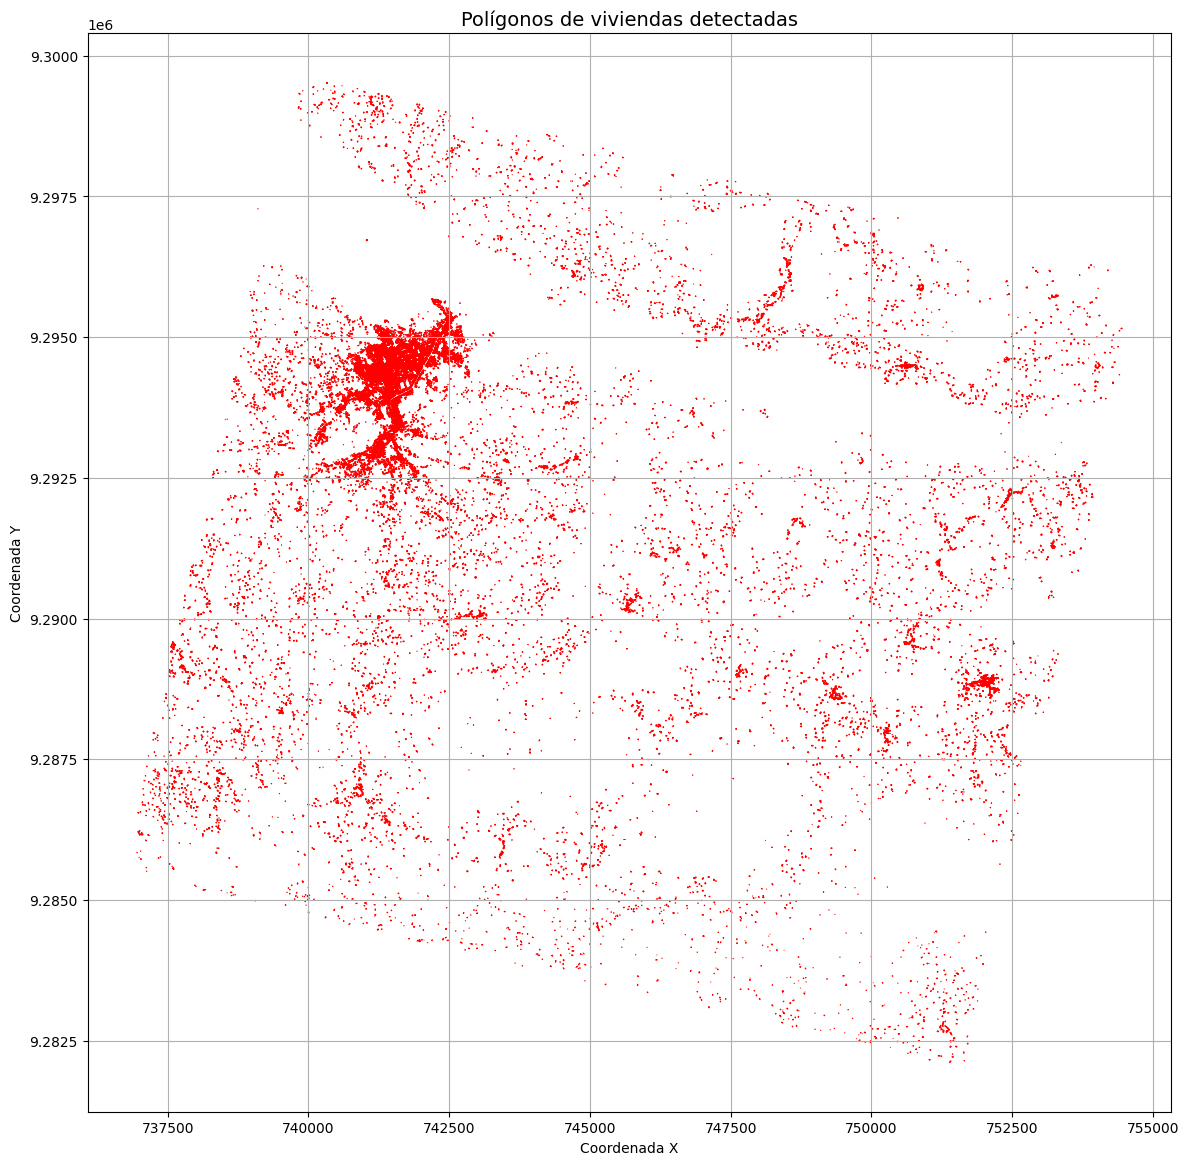

In [ ]:

# RUTA DEL GPKG

#archivo_gpkg = r "tu ruta a viviendas.gpkg"
# Si tu GPKG tiene una sola capa
viviendas = gpd.read_file(archivo_gpkg)


# GRAFICAR POLÍGONOS

fig, ax = plt.subplots(figsize=(12, 12))

viviendas.plot(
    ax=ax,
    facecolor="none",
    edgecolor="red",
    linewidth=0.7
)

ax.set_title("Polígonos de viviendas detectadas", fontsize=14)
ax.set_xlabel("Coordenada X")
ax.set_ylabel("Coordenada Y")
ax.grid(True)

plt.tight_layout()
plt.show()

# Inicio proceso

## Recorte de los puntos georrferenciados para quedarse solo con los puntos que caen dentro de la imagen satelital 

In [ ]:

#ruta_puntos = r "ruta capa de puntos"
#ruta_raster = r "ruta capa raster"
#ruta_salida = r "ruta capa de salida"

#ruta_departamento_gpkg = r "ruta capa de departamentos"
#ruta_provincia_gpkg = r "ruta capa de provincias"
#ruta_distrito_gpkg = r "ruta capa de distritos"    

#ruta_salida_png = r "ruta capa de salida en formato PNG"

In [ ]:
 ## Recorte de AOI

os.makedirs(os.path.dirname(ruta_salida), exist_ok=True)

for ext in [".shp", ".shx", ".dbf", ".prj", ".cpg"]:
    f = ruta_salida.replace(".shp", ext)
    if os.path.exists(f):
        os.remove(f)

# 
# LEER PUNTOS
# 

puntos = gpd.read_file(ruta_puntos)

# 
# LEER RASTER
# 

with rasterio.open(ruta_raster) as src:

    raster_crs = src.crs
    bandas = src.count

    if puntos.crs != raster_crs:
        puntos = puntos.to_crs(raster_crs)

    coords = [(geom.x, geom.y) for geom in puntos.geometry]

    # Leer TODAS las bandas en cada punto
    valores = np.array([val for val in src.sample(coords)])

# 
# FILTRAR DONDE HAYA INFORMACIÓN REAL
# 

# Mantener puntos donde NO todas las bandas sean 0
mascara_valida = ~(np.all(valores == 0, axis=1))

puntos_validos = puntos[mascara_valida].copy()

print("Puntos originales:", len(puntos))
print("Puntos dentro reales:", len(puntos_validos))

# 
# EXPORTAR
# 

puntos_validos.to_file(
    ruta_salida,
    driver="ESRI Shapefile",
    index=False
)

print("Proceso terminado correctamente")


Puntos originales: 91234
Puntos dentro reales: 6830
Proceso terminado correctamente


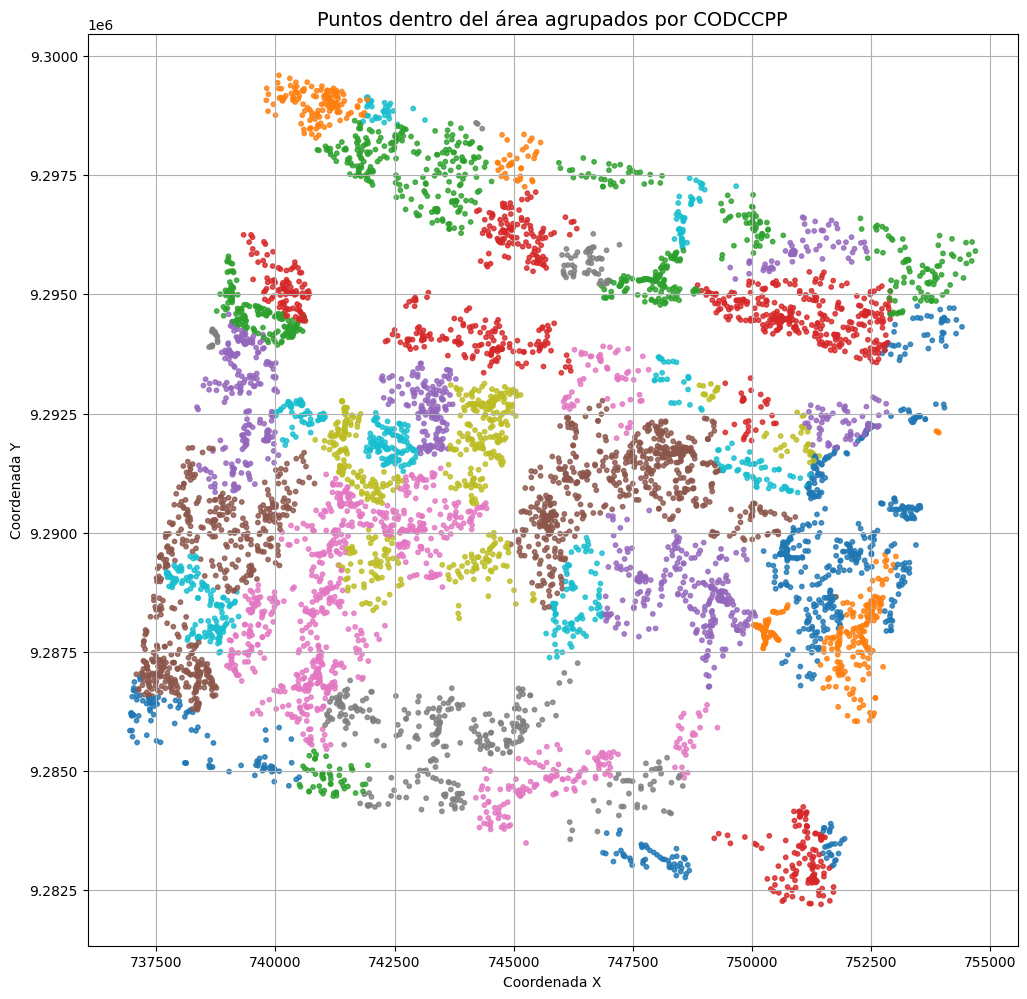

In [9]:
# REPRESENTACIÓN GRÁFICA DE PUNTOS AGRUPADOS POR CODCCPP
# 

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 12))

puntos_validos.plot(
    ax=ax,
    column="CODCCPP",      # Campo para agrupar por centro poblado
    categorical=True,      # Trata CODCCPP como categoría
    legend=False,           # Muestra leyenda
    markersize=10,
    alpha=0.8
)

ax.set_title("Puntos dentro del área agrupados por CODCCPP", fontsize=14)
ax.set_xlabel("Coordenada X")
ax.set_ylabel("Coordenada Y")
ax.grid(True)

plt.show()

Puntos originales: 6830
Puntos dentro del raster: 6830


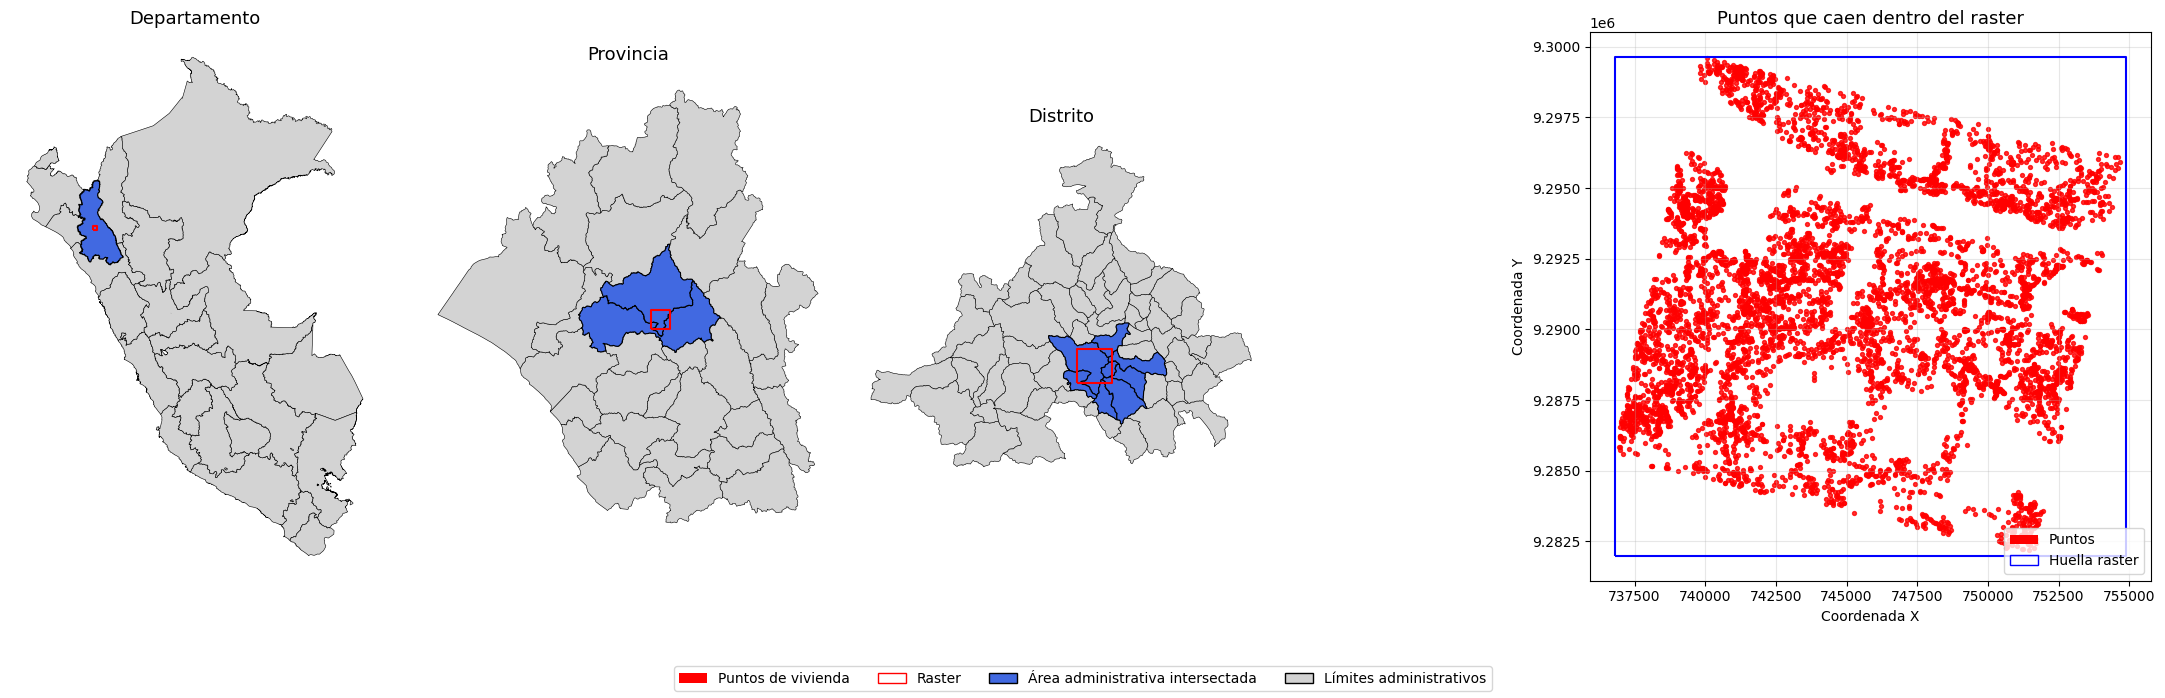

Gráfico guardado en:
C:\Users\ABUDABI\Downloads\CAPAS DE ENTRADA\CAPAS_LIMITES_PERU\grafica_puntos_contexto_admin_1.png


In [ ]:
import os
import numpy as np
import geopandas as gpd
import rasterio
from shapely.geometry import box
import matplotlib.pyplot as plt
from matplotlib.patches import Patch



# RUTAS

# ruta_puntos = r"ruta a puntos.shp"

#ruta_departamento = r"ruta a departamento.gpkg"
#ruta_provincia = r"ruta a provincia.gpkg"
#ruta_distrito = r"ruta a distrito.gpkg"

#ruta_salida_png = r"ruta a grafica_puntos_contexto_admin_1.png"


# LEER RASTER Y CREAR HUELLA

with rasterio.open(ruta_raster) as src:
    raster_crs = src.crs
    raster_bounds = src.bounds
    huella_raster = box(*raster_bounds)

huella_gdf = gpd.GeoDataFrame(
    {"nombre": ["Raster"]},
    geometry=[huella_raster],
    crs=raster_crs
)

# LEER PUNTOS Y FILTRAR SOLO LOS QUE CAEN EN EL RASTER

puntos = gpd.read_file(ruta_puntos)

if puntos.crs != raster_crs:
    puntos = puntos.to_crs(raster_crs)

puntos_dentro = puntos[puntos.geometry.within(huella_raster)].copy()

print("Puntos originales:", len(puntos))
print("Puntos dentro del raster:", len(puntos_dentro))


# LEER CAPAS ADMINISTRATIVAS

departamentos = gpd.read_file(ruta_departamento).to_crs(raster_crs)
provincias = gpd.read_file(ruta_provincia).to_crs(raster_crs)
distritos = gpd.read_file(ruta_distrito).to_crs(raster_crs)


# SELECCIONAR ÁREAS ADMINISTRATIVAS DONDE CAE EL RASTER

departamento_sel = departamentos[departamentos.intersects(huella_raster)].copy()
provincia_sel = provincias[provincias.intersects(huella_raster)].copy()
distrito_sel = distritos[distritos.intersects(huella_raster)].copy()


# GRAFICA

fig, axes = plt.subplots(
    nrows=1,
    ncols=4,
    figsize=(25, 7),
    gridspec_kw={"width_ratios": [1, 1, 1, 2.8]}
)


# Departamento -> Provincia -> Distrito -> Puntos

ax_dep = axes[0]
ax_prov = axes[1]
ax_dist = axes[2]
ax_puntos = axes[3]


# 1. PUNTOS DENTRO DEL RASTER

if len(puntos_dentro) > 0:
    puntos_dentro.plot(
        ax=ax_puntos,
        color="red",
        markersize=8,
        alpha=0.8
    )

huella_gdf.boundary.plot(
    ax=ax_puntos,
    color="blue",
    linewidth=1.5
)

ax_puntos.set_title("Puntos que caen dentro del raster", fontsize=13)
ax_puntos.set_xlabel("Coordenada X")
ax_puntos.set_ylabel("Coordenada Y")
ax_puntos.grid(True, alpha=0.3)

ax_puntos.legend(
    handles=[
        Patch(facecolor="red", label="Puntos"),
        Patch(facecolor="none", edgecolor="blue", label="Huella raster")
    ],
    loc="lower right"
)


# 2. CONTEXTO DEPARTAMENTAL


departamentos.plot(
    ax=ax_dep,
    color="lightgray",
    edgecolor="black",
    linewidth=0.4
)

departamento_sel.plot(
    ax=ax_dep,
    color="royalblue",
    edgecolor="black",
    linewidth=0.8
)

huella_gdf.boundary.plot(
    ax=ax_dep,
    color="red",
    linewidth=1.5
)

ax_dep.set_title("Departamento", fontsize=13)
ax_dep.set_axis_off()


# 3. CONTEXTO PROVINCIAL

if len(departamento_sel) > 0:
    depto_geom = departamento_sel.unary_union
    provincias_contexto = provincias[provincias.intersects(depto_geom)].copy()
else:
    provincias_contexto = provincias.copy()

provincias_contexto.plot(
    ax=ax_prov,
    color="lightgray",
    edgecolor="black",
    linewidth=0.4
)

provincia_sel.plot(
    ax=ax_prov,
    color="royalblue",
    edgecolor="black",
    linewidth=0.8
)

huella_gdf.boundary.plot(
    ax=ax_prov,
    color="red",
    linewidth=1.5
)

ax_prov.set_title("Provincia", fontsize=13)
ax_prov.set_axis_off()


# 4. CONTEXTO DISTRITAL

if len(provincia_sel) > 0:
    prov_geom = provincia_sel.unary_union
    distritos_contexto = distritos[distritos.intersects(prov_geom)].copy()
else:
    distritos_contexto = distritos.copy()

distritos_contexto.plot(
    ax=ax_dist,
    color="lightgray",
    edgecolor="black",
    linewidth=0.4
)

distrito_sel.plot(
    ax=ax_dist,
    color="royalblue",
    edgecolor="black",
    linewidth=0.8
)

huella_gdf.boundary.plot(
    ax=ax_dist,
    color="red",
    linewidth=1.5
)

ax_dist.set_title("Distrito", fontsize=13)
ax_dist.set_axis_off()


# LEYENDA GENERAL

fig.legend(
    handles=[
        Patch(facecolor="red", label="Puntos de vivienda"),
        Patch(facecolor="none", edgecolor="red", label="Raster"),
        Patch(facecolor="royalblue", edgecolor="black", label="Área administrativa intersectada"),
        Patch(facecolor="lightgray", edgecolor="black", label="Límites administrativos")
    ],
    loc="lower center",
    ncol=4,
    fontsize=10
)

plt.tight_layout(rect=[0, 0.08, 1, 1])

os.makedirs(os.path.dirname(ruta_salida_png), exist_ok=True)

plt.savefig(
    ruta_salida_png,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Gráfico guardado en:")
print(ruta_salida_png)

## Carga de las capas 
- Capa de viviendas detectadas (polignos sin atributos "CODCCPP")
- Capa de puntos georreferenciados con UBIGEO y CODCCPP

In [ ]:
import geopandas as gpd

# Definimos las rutas de los puntos georreferenciados
#ruta_puntos = r"ruta a puntos.shp"
# definimos la ruta del archivo de viviendas en polígonos
#ruta_viviendas = r"ruta a viviendas.gpkg"
# Ruta de salida para el resultado final
#ruta_salida =r"ruta a salida.gpkg"  

puntos = gpd.read_file(ruta_puntos)
viviendas = gpd.read_file(ruta_viviendas)

print("Puntos cargados:", len(puntos))
print("Viviendas cargadas:", len(viviendas))


Puntos cargados: 6830
Viviendas cargadas: 40769


## Parámetros

In [17]:

campo_codigo = "CODCCPP"

# Número de vecinos para propagar el CODCCPP.
# Puedes probar con 3, 5, 7 o 9.
k_vecinos = 5

# Distancia máxima permitida entre un punto censal y una vivienda detectada.
# Debe estar en metros si tu CRS es UTM.
distancia_max_punto_vivienda = 100

# Distancia máxima para propagar CODCCPP desde viviendas semilla.
# Ajustar según dispersión rural.
distancia_max_propagacion = 500

# CRS proyectado recomendado para Perú.
# Usa EPSG:32717 o EPSG:32718 según la zona UTM.
# Si tus datos ya están en UTM, puedes usar el CRS de viviendas.
crs_trabajo = "EPSG:32718"


## Reproyeccion CRS

In [19]:
## Reproyectar a CRS de trabajo
puntos = puntos.to_crs(crs_trabajo)
viviendas = viviendas.to_crs(crs_trabajo)

# Limpiar geometrías inválidas si existieran
viviendas["geometry"] = viviendas.geometry.buffer(0)

# Crear ID único para cada vivienda
viviendas = viviendas.reset_index(drop=True)
viviendas["ID_VIV"] = viviendas.index

## Creamos centroides de viviendas

In [20]:
viviendas_centroides = viviendas.copy()
viviendas_centroides["geometry"] = viviendas.geometry.centroid

### Etapa 1: asignar cada punto al polígono de vivienda más cercano

In [21]:
puntos_nearest = gpd.sjoin_nearest(
    puntos[[campo_codigo, "geometry"]],
    viviendas_centroides[["ID_VIV", "geometry"]],
    how="left",
    distance_col="dist_punto_viv"
)

# Filtrar asignaciones demasiado lejanas
puntos_nearest = puntos_nearest[
    puntos_nearest["dist_punto_viv"] <= distancia_max_punto_vivienda
].copy()

print("Puntos asignados a vivienda cercana:", len(puntos_nearest))

# En caso varios puntos caigan cerca de la misma vivienda,
# se conserva el punto más cercano.
puntos_nearest = puntos_nearest.sort_values("dist_punto_viv")
puntos_nearest = puntos_nearest.drop_duplicates(subset="ID_VIV", keep="first")

# Crear tabla de viviendas semilla con CODCCPP
semillas = puntos_nearest[["ID_VIV", campo_codigo, "dist_punto_viv"]].copy()
semillas = semillas.rename(columns={
    campo_codigo: "CODCCPP_SEMILLA"
})

# Unir CODCCPP semilla a viviendas
viviendas = viviendas.merge(
    semillas,
    on="ID_VIV",
    how="left"
)

print("Viviendas semilla con CODCCPP:", viviendas["CODCCPP_SEMILLA"].notna().sum())


Puntos asignados a vivienda cercana: 11519
Viviendas semilla con CODCCPP: 9699


### Etapa 2: propagar el CODCCPP al resto de viviendas

In [24]:

# Recalcular centroides después del merge
viviendas_centroides = viviendas.copy()
viviendas_centroides["geometry"] = viviendas.geometry.centroid

# Coordenadas de todos los centroides
viviendas_centroides["x"] = viviendas_centroides.geometry.x
viviendas_centroides["y"] = viviendas_centroides.geometry.y

# Viviendas semilla
semillas_gdf = viviendas_centroides[
    viviendas_centroides["CODCCPP_SEMILLA"].notna()
].copy()

# Viviendas sin código
sin_codigo_gdf = viviendas_centroides[
    viviendas_centroides["CODCCPP_SEMILLA"].isna()
].copy()

if len(semillas_gdf) == 0:
    raise ValueError("No se generaron viviendas semilla. Aumenta distancia_max_punto_vivienda.")

print("Viviendas sin CODCCPP antes de propagación:", len(sin_codigo_gdf))

# Datos de entrenamiento: viviendas semilla
X_train = semillas_gdf[["x", "y"]].values
y_train = semillas_gdf["CODCCPP_SEMILLA"].astype(str).values

# Datos a clasificar: viviendas sin código
X_pred = sin_codigo_gdf[["x", "y"]].values

# Ajustar k si hay pocas semillas
k_real = min(k_vecinos, len(semillas_gdf))

knn = KNeighborsClassifier(
    n_neighbors=k_real,
    weights="distance"
)

knn.fit(X_train, y_train)

# Predecir CODCCPP para viviendas sin código
cod_pred = knn.predict(X_pred)

# Calcular distancia al vecino semilla más cercano
distancias, indices = knn.kneighbors(X_pred, n_neighbors=1)
distancia_minima = distancias[:, 0]

sin_codigo_gdf["CODCCPP_PROPAGADO"] = cod_pred
sin_codigo_gdf["DIST_SEMILLA_MIN"] = distancia_minima

# Aplicar umbral de distancia máxima de propagación
sin_codigo_gdf.loc[
    sin_codigo_gdf["DIST_SEMILLA_MIN"] > distancia_max_propagacion,
    "CODCCPP_PROPAGADO"
] = np.nan

Viviendas sin CODCCPP antes de propagación: 31070


In [25]:

viviendas["CODCCPP_FINAL"] = viviendas["CODCCPP_SEMILLA"]

# Crear diccionario ID_VIV -> CODCCPP_PROPAGADO
dict_prop = sin_codigo_gdf.set_index("ID_VIV")["CODCCPP_PROPAGADO"].to_dict()
dict_dist = sin_codigo_gdf.set_index("ID_VIV")["DIST_SEMILLA_MIN"].to_dict()

# Asignar CODCCPP propagado donde no había semilla
viviendas["CODCCPP_FINAL"] = viviendas.apply(
    lambda row: dict_prop.get(row["ID_VIV"], row["CODCCPP_FINAL"])
    if pd.isna(row["CODCCPP_FINAL"])
    else row["CODCCPP_FINAL"],
    axis=1
)

viviendas["DIST_SEMILLA_MIN"] = viviendas["ID_VIV"].map(dict_dist)

# Tipo de asignación
viviendas["TIPO_ASIG"] = np.where(
    viviendas["CODCCPP_SEMILLA"].notna(),
    "SEMILLA_PUNTO_CERCANO",
    np.where(
        viviendas["CODCCPP_FINAL"].notna(),
        "PROPAGADO_KNN",
        "SIN_ASIGNAR"
    )
)


In [ ]:

print("Resumen de asignación:")
print(viviendas["TIPO_ASIG"].value_counts())

print("\nViviendas por CODCCPP:")
print(viviendas["CODCCPP_FINAL"].value_counts(dropna=False))


Resumen de asignación:
TIPO_ASIG
PROPAGADO_KNN            20573
SIN_ASIGNAR              10497
SEMILLA_PUNTO_CERCANO     9699
Name: count, dtype: int64

Viviendas por CODCCPP:
CODCCPP_FINAL
NaN     10497
0039     2500
0128     2040
0040     1649
0129      998
        ...  
0093       28
0016       26
0110       13
0017        8
0084        1
Name: count, Length: 87, dtype: int64


In [ ]:
# EXPORTAR RESULTADO

os.makedirs(os.path.dirname(ruta_salida), exist_ok=True)

viviendas.to_file(
    ruta_salida,
    driver="GPKG",
    layer="viviendas_con_CODCCPP"
)

print("Proceso terminado correctamente.")
print("Archivo generado:")
print(ruta_salida)

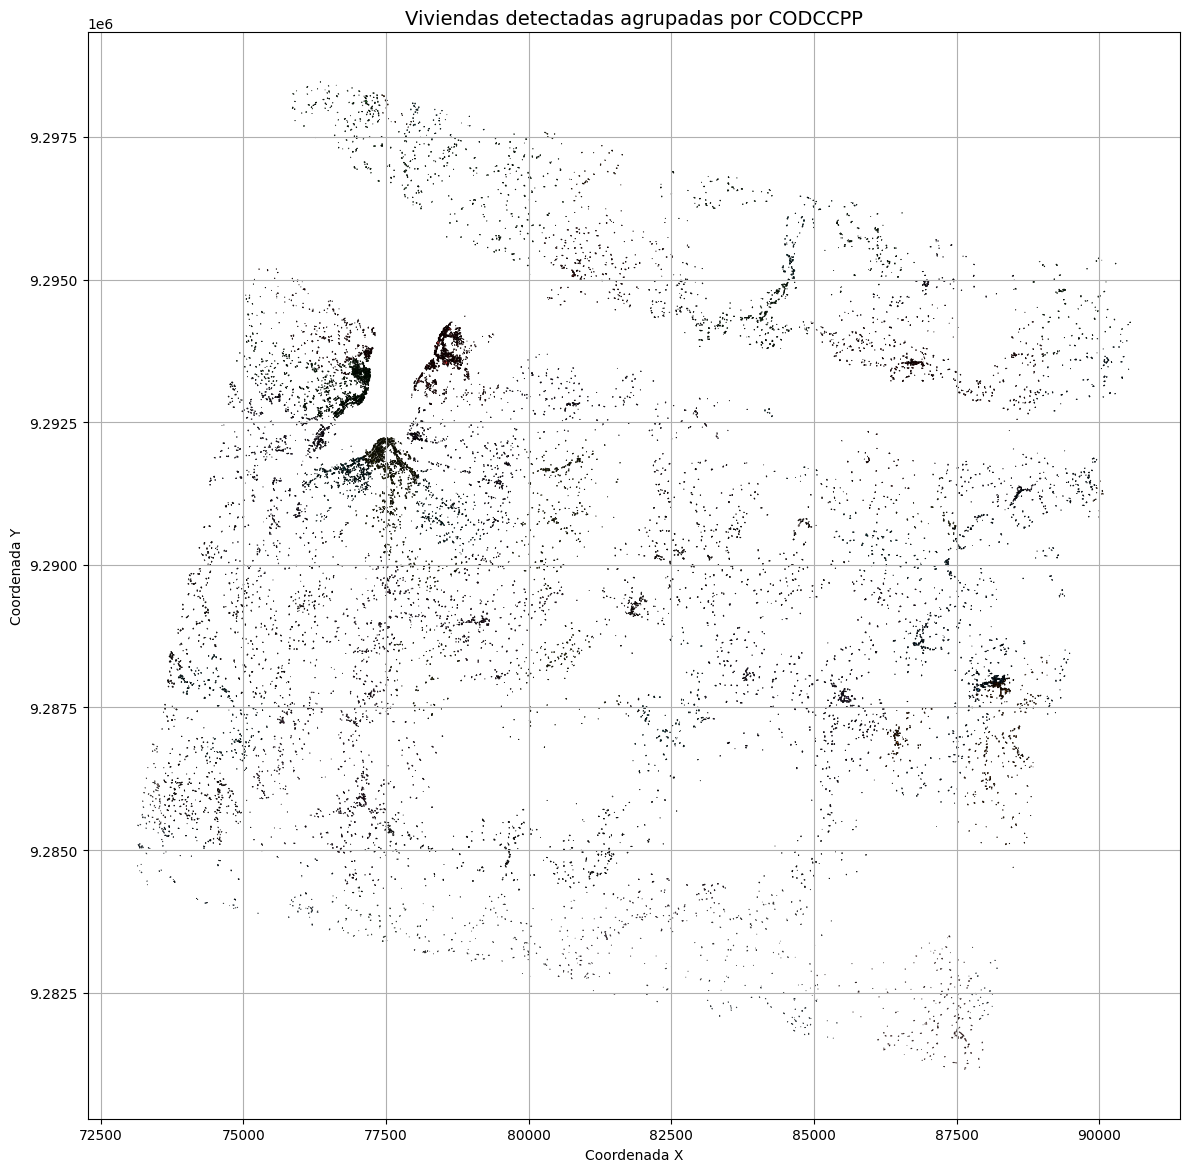

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

#archivo_gpkg = r"ruta a viviendas con CODCCPP.gpkg"
viviendas = gpd.read_file(archivo_gpkg)

atributo_clave = "CODCCPP_FINAL"

fig, ax = plt.subplots(figsize=(12, 12))

viviendas.plot(
    ax=ax,
    column=atributo_clave,
    categorical=True,
    legend=False,
    edgecolor="black",
    linewidth=0.5,
    alpha=0.7
)

ax.set_title("Viviendas detectadas agrupadas por CODCCPP", fontsize=14)
ax.set_xlabel("Coordenada X")
ax.set_ylabel("Coordenada Y")
ax.grid(True)

plt.tight_layout()
plt.show()

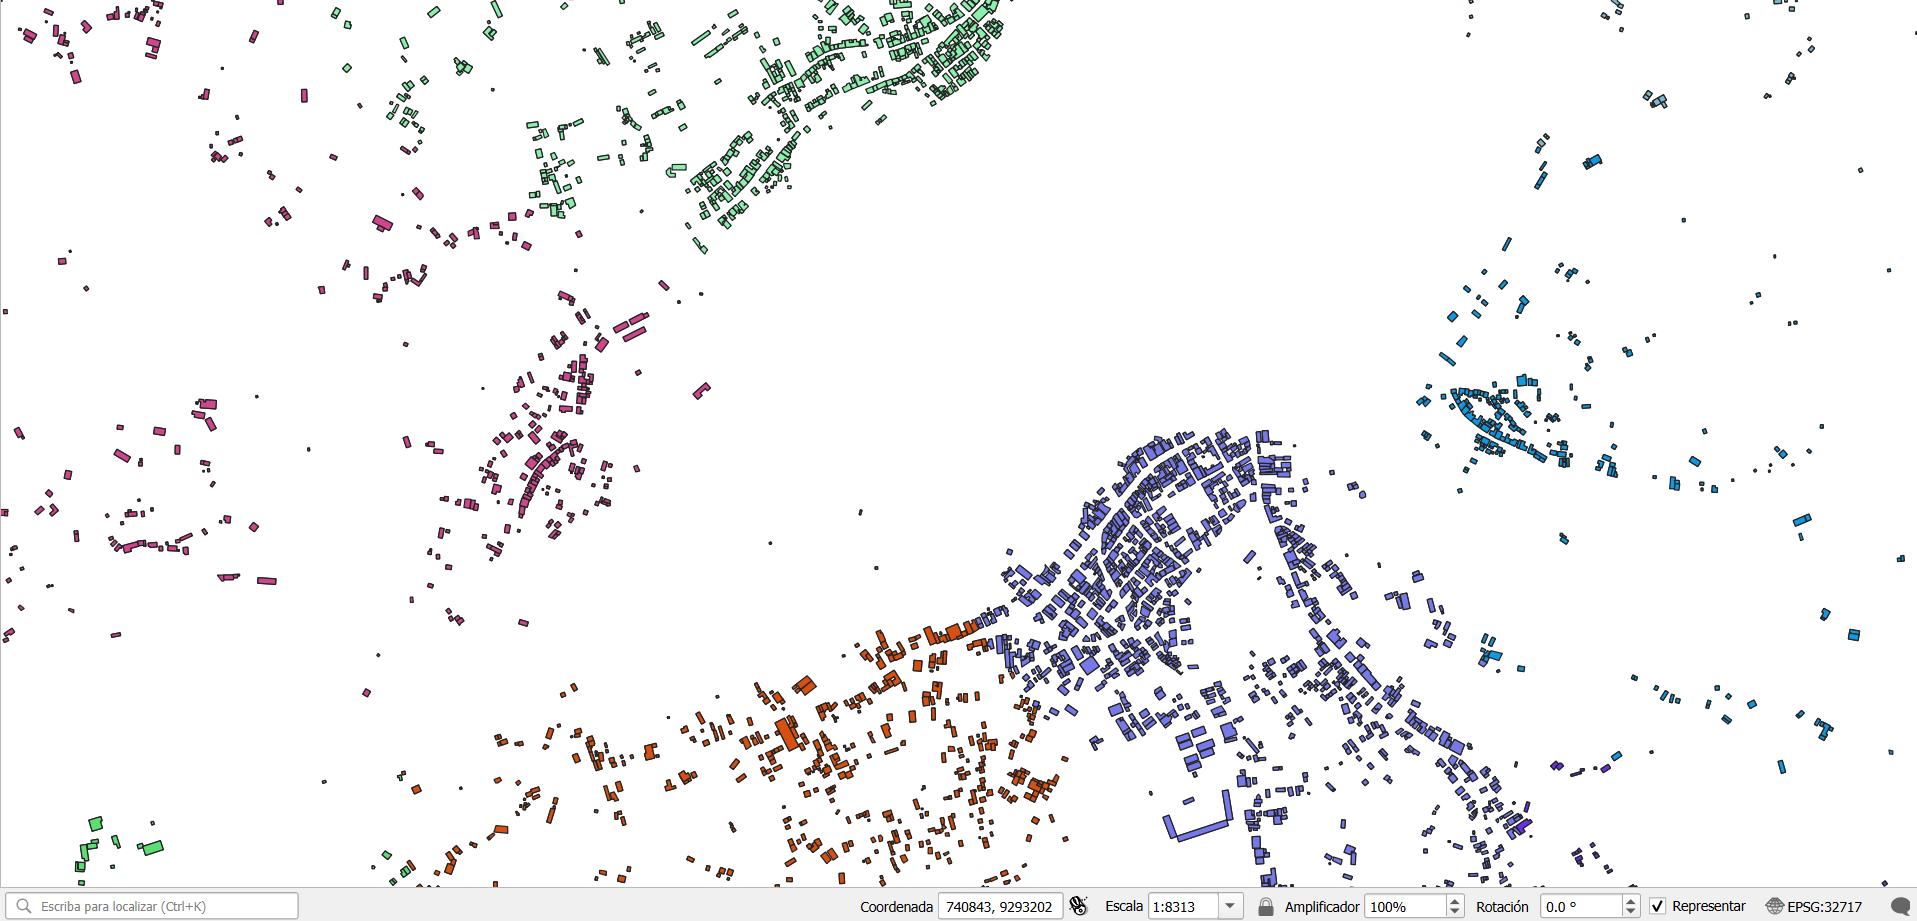

## VORONOI

In [ ]:

# ==========================================
# 1. Configuración de rutas
# ==========================================
#archivo_puntos = r"ruta a puntos.shp"
#archivo_tif = r"ruta a imagen.tif"

#archivo_salida = r"ruta a salida.gpkg"
#atributo_clave = "CODCCPP_FINAL"

try:
    # 2. Extraer la HUELLA EXACTA (Sin NoData) del TIF
    print("Analizando los píxeles de la imagen satelital para extraer la huella real...")
    with rasterio.open(archivo_tif) as src:
        # Leemos toda la imagen
        arr = src.read()
        
        # Aplicamos tu lógica: Creamos una máscara donde NO todas las bandas sean 0
        # axis=0 compara a través de las bandas de la imagen
        mascara_valida = np.any(arr != 0, axis=0).astype('uint8')
        
        print("Convirtiendo la huella de píxeles a un polígono vectorial...")
        # rasterio.features.shapes convierte los píxeles válidos (1) en geometrías de polígono
        generador_geometrias = shapes(mascara_valida, mask=mascara_valida.astype(bool), transform=src.transform)
        
        # Extraemos las geometrías y las convertimos al formato de Shapely
        poligonos_huella = [shape(geom) for geom, valor in generador_geometrias if valor == 1]
        
        # Fusionamos todos los polígonos resultantes en uno solo (por si la imagen tiene huecos)
        huella_total = unary_union(poligonos_huella)
        crs_tif = src.crs

    # Creamos un GeoDataFrame con esta huella exacta
    gdf_huella_tif = gpd.GeoDataFrame({'geometry': [huella_total]}, crs=crs_tif)

    # 3. Cargar y preparar Puntos
    print("Cargando capa de puntos...")
    gdf_puntos = gpd.read_file(archivo_puntos)
    gdf_puntos = gdf_puntos[(gdf_puntos[atributo_clave] != 0) & (gdf_puntos[atributo_clave] != '0')]
    gdf_puntos = gdf_puntos.drop_duplicates(subset=['geometry']).reset_index(drop=True)

    # Verificar que usen el mismo CRS
    if gdf_puntos.crs != gdf_huella_tif.crs:
        print("Proyectando la huella de la imagen al mismo sistema de los puntos...")
        gdf_huella_tif = gdf_huella_tif.to_crs(gdf_puntos.crs)

    # 4. Calcular Voronoi
    print("Calculando red de Voronoi...")
    # Usamos un sobre (envelope) holgado para el cálculo inicial
    limite_exterior = gdf_puntos.unary_union.convex_hull.buffer(2000)
    voronoi_geoms = voronoi_diagram(gdf_puntos.unary_union, envelope=limite_exterior)
    gdf_voronoi = gpd.GeoDataFrame(geometry=[geom for geom in voronoi_geoms.geoms], crs=gdf_puntos.crs)

    # 5. Asignar UBIGEO y Disolver
    print("Asignando UBIGEO a cada polígono...")
    # Usamos un punto interno representativo para el join espacial
    gdf_puntos['rep_point'] = gdf_puntos.geometry
    gdf_voronoi = gpd.sjoin(gdf_voronoi, gdf_puntos[[atributo_clave, 'geometry']], how='left', predicate='intersects')

    print("Disolviendo límites internos por UBIGEO...")
    gdf_final = gdf_voronoi.dissolve(by=atributo_clave).reset_index()
    if 'index_right' in gdf_final.columns:
        gdf_final = gdf_final.drop(columns=['index_right'])

    # 6. RECORTAR (CLIP) CON LA HUELLA REAL (SIN NODATA)
    print("Recortando los polígonos al área exacta con datos de la imagen satelital...")
    gdf_recortado = gpd.clip(gdf_final, gdf_huella_tif)

    # 7. Guardamos Resultado
    print("Guardando capa final...")
    gdf_recortado.to_file(archivo_salida, driver="GPKG")
    print("¡Proceso completado! Los bordes ahora calzarán perfectamente con los píxeles útiles de tu imagen.")

except Exception as e:
    print(f"Ocurrió un error: {e}")

Analizando los píxeles de la imagen satelital para extraer la huella real...
Convirtiendo la huella de píxeles a un polígono vectorial...
Cargando capa de puntos...
Proyectando la huella de la imagen al mismo sistema de los puntos...
Calculando red de Voronoi...
Asignando UBIGEO a cada polígono...
Disolviendo límites internos por UBIGEO...
Recortando los polígonos al área exacta con datos de la imagen satelital...
Guardando capa final...
¡Proceso completado! Los bordes ahora calzarán perfectamente con los píxeles útiles de tu imagen.


Graficando resultado Voronoi...


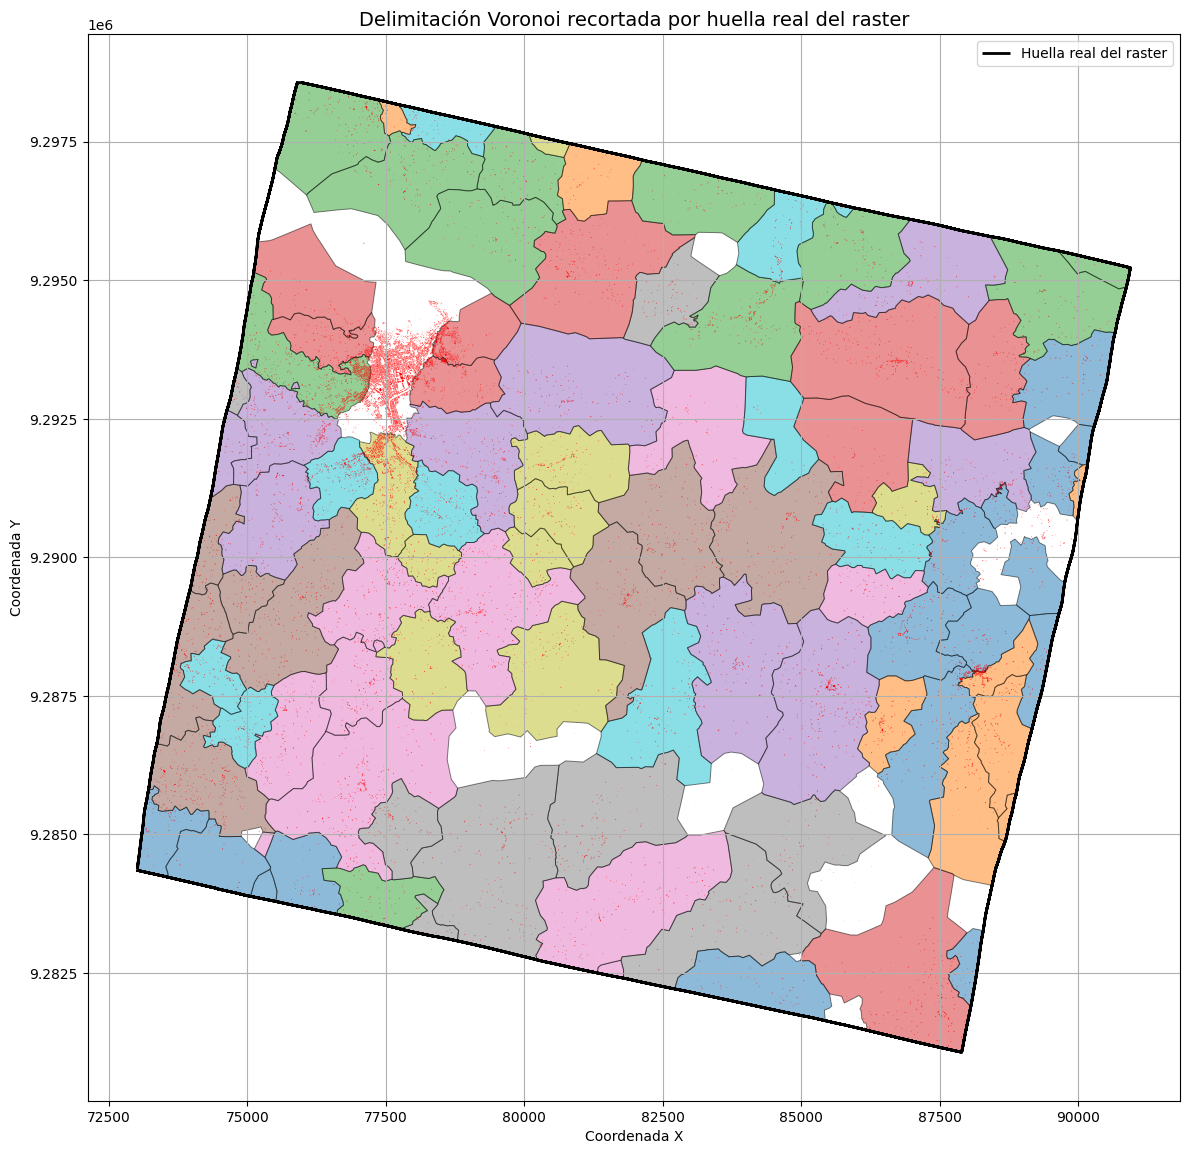

In [ ]:
# Grafica de resultado Voronoi recortado

print("Graficando resultado Voronoi...")

fig, ax = plt.subplots(figsize=(12, 12))

# Grafica de la huella del raster
gdf_huella_tif.boundary.plot(
    ax=ax,
    linewidth=2,
    color="black",
    label="Huella real del raster"
)

# Grafica de polígonos Voronoi recortados por CODCCPP
gdf_recortado.plot(
    ax=ax,
    column=atributo_clave,
    categorical=True,
    alpha=0.5,
    edgecolor="black",
    linewidth=0.7,
    legend=True
)

# Grafica de puntos/viviendas de referencia
gdf_puntos.plot(
    ax=ax,
    color="red",
    markersize=8,
    label="Viviendas / puntos base"
)

ax.set_title("Delimitación Voronoi recortada por huella real del raster", fontsize=14)
ax.set_xlabel("Coordenada X")
ax.set_ylabel("Coordenada Y")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

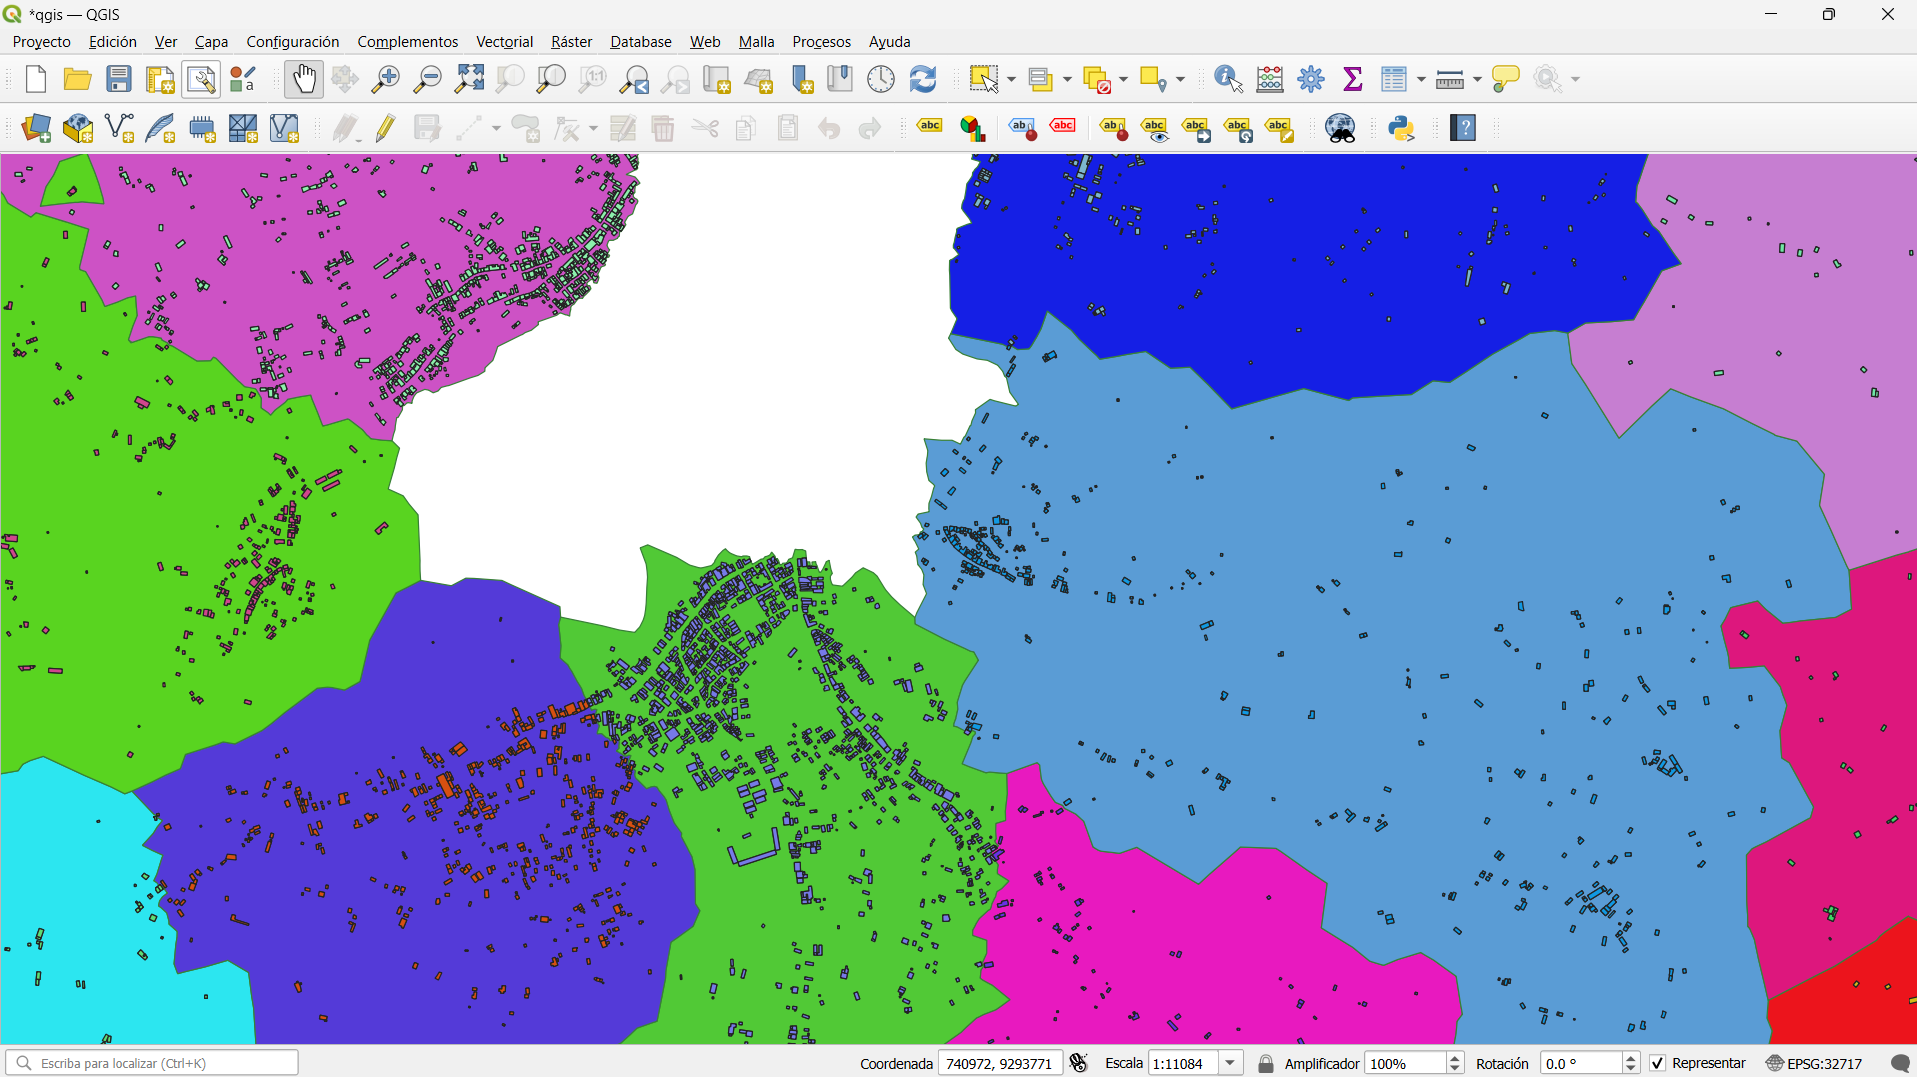